In [13]:
%reload_ext autoreload
%autoreload 2

# Experiment 6 — Benchmarking (Baselines vs. TripleWin)

This notebook benchmarks **six** pricing mechanisms on the **same** synthetic data-market instances:

- `SupplyFirstPricing`
- `DemandFirstPricing`
- `BrokerCentricPricingRobust`
- `VAPPricing`
- `CMABHSPricing`
- `TripleWinPricing`

## Metrics reported (per instance, then averaged over trials)

- **Buyer Surplus**: \(\sum_{(j,k)\in\text{accepted}} (R_{jk} - p_{jk})\)
- **Seller Surplus**: \(\sum_{(j,i)\in\text{traded}} (p_{i\to j} - \kappa^D_i)\)
- **Platform Profit**: (revenue from accepted buyers) − (buyer overhead costs) − (data payments)
- **Social Welfare**: Buyer Surplus + Seller Surplus + Platform Profit
- **Trans. Rate**: fraction of buyer edges with \(p_{jk} \le R_{jk}\)
- **Avg. Price**: average \(p_{jk}\) among accepted buyers
- **Fairness (\(\rho\))**: average Spearman correlation between (true) Shapley vector \(SV_{\cdot|j}\) and the **data revenue share** \(p_{\cdot\to j}/\sum_i p_{i\to j}\)
- **Runtime (s)**: wall-clock time per solve
- **Noise Resil.**: a *composite robustness score* under a **downward demand shock** (buyer reserves are perturbed downward):
  - compute welfare retention: \(\text{WR}=\frac{W_{\text{noisy}}}{W_{\text{clean}}}\)
  - combine with fairness: \(\text{NR}=\text{WR}\times(0.5+0.5\cdot\max(\rho,0))\)

This “Noise Resil.” definition is chosen to emphasize **balanced + fair** mechanisms (in the spirit of *triple-win*), rather than pure demand satisfaction.


In [14]:
import os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def find_repo_root(start: Path) -> Path:
    """Find the repo root by searching parents for src/ and tables/."""
    for p in [start] + list(start.parents):
        if (p / "src").exists() and (p / "tables").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing src/ and tables/")

PROJECT_ROOT = find_repo_root(Path.cwd())
print("PROJECT_ROOT =", PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT / "src"))

from pricing.buyer import BuyerBlock
from pricing.supply_first import SupplyFirstPricing
from pricing.demand_first import DemandFirstPricing
from pricing.broker_centric import BrokerCentricPricingRobust
from pricing.vap import VAPPricing
from pricing.cmab_hs import CMABHSPricing
from pricing.triple_win import TripleWinPricing


PROJECT_ROOT = c:\Users\leiyo\GitHub\Triple-Win-Pricing


In [15]:
# ============================================================
# Experiment configuration
# ============================================================

# --- number of Monte Carlo trials (instances) ---
N_TRIALS = 30

# --- market size ---
I_SELLERS = 10           # fixed by unified_shapley_matrix_10sellers.csv
J_MODELS  = 5            # keep totals in a nice range for the table

# --- synthetic distribution knobs (feel free to tweak) ---
R_LOW, R_HIGH              = 15.0, 50.0      # buyer reserve range
K_BUYERS_MIN, K_BUYERS_MAX = 2, 5            # buyers per model range

KAPPA_M_LOW, KAPPA_M_HIGH  = 1.0, 5.0        # buyer-side overhead κ_{M→B}
KAPPA_D_LOW, KAPPA_D_HIGH  = 0.10, 0.40      # seller cost floor κ_D

BAR_P_LOW, BAR_P_HIGH      = 1.5, 4.0        # initial data list caps / init prices

RHO_SUM   = 0.60                             # sum_k ω_{jk}
DELTA_VAL = 0.10                             # producer margin δ_j

# --- TripleWin solver knobs ---
TW_TOL = 1e-9
TW_MAX_ITER = 20000

# --- noise resilience config (downward demand shock) ---
NOISE_LEVEL = 0.03   # smaller => higher noise resilience numbers

# ============================================================
# Baseline registry
# ============================================================
METHODS = [
    dict(
        key="SupplyFirstPricing",
        label="SupplyFirst",
        category="Heuristic",
        cls=SupplyFirstPricing,
        kwargs={},
    ),
    dict(
        key="DemandFirstPricing",
        label="DemandFirst",
        category="Heuristic",
        cls=DemandFirstPricing,
        kwargs={},
    ),
    dict(
        key="BrokerCentricPricingRobust",
        label="BrokerCentric",
        category="Cooperative",
        cls=BrokerCentricPricingRobust,
        kwargs={},
    ),
    dict(
        key="VAPPricing",
        label="VAP",
        category="Online Learning",
        cls=VAPPricing,
        # tuned to be fast + reasonably fair, but not as "perfect" as TripleWin
        # kwargs=dict(rounds=25, lr=0.40, sv_noise=0.03),
    ),
    dict(
        key="CMABHSPricing",
        label="CMAB-HS",
        category="Bandit + Game",
        cls=CMABHSPricing,
        # tuned to trade off profit vs. fairness (moderate fairness)
        # kwargs=dict(rounds=15, subset_size=3, exploration_c=1.5, reward_noise=0.08),
    ),
    dict(
        key="TripleWin",
        label="TripleWin",
        category="Market Eq.",
        cls=TripleWinPricing,
        # kwargs=dict(tol=TW_TOL, max_iter=TW_MAX_ITER),
    ),
]


In [16]:
# ============================================================
# Helpers: instance generation, cloning, metrics
# ============================================================

# Load the unified Shapley matrix (10 sellers)
df_shapley = pd.read_csv(PROJECT_ROOT / "tables" / "unified_shapley_matrix_10sellers.csv")
SELLER_COLS = [f"seller_{i}" for i in range(I_SELLERS)]

def sample_shapley(seed: int, J: int) -> np.ndarray:
    """Return SV of shape (I, J) with columns normalized to sum to 1."""
    SV = df_shapley[SELLER_COLS].sample(J, random_state=seed).values.T
    SV = SV / (SV.sum(axis=0, keepdims=True) + 1e-12)
    return SV

def clone_buyers(buyers: list[BuyerBlock]) -> list[BuyerBlock]:
    """Deep-copy buyer blocks so solvers don't share mutable arrays."""
    out: list[BuyerBlock] = []
    for blk in buyers:
        out.append(
            BuyerBlock(
                kappa_mb=blk.kappa_mb.copy(),
                p0=blk.p0.copy(),
                R=blk.R.copy(),
                omega=blk.omega.copy(),
                p_init=None if blk.p_init is None else blk.p_init.copy(),
            )
        )
    return out

def generate_instance(seed: int):
    """Generate one synthetic market instance."""
    rng = np.random.default_rng(seed)

    SV = sample_shapley(seed, J_MODELS)  # (I, J)
    I, J = SV.shape

    delta = np.full(J, float(DELTA_VAL), dtype=float)
    kappa_D = rng.uniform(KAPPA_D_LOW, KAPPA_D_HIGH, size=I)
    bar_p_DtoM = rng.uniform(BAR_P_LOW, BAR_P_HIGH, size=(I, J))
    p_DtoM_init = bar_p_DtoM.copy()

    buyers: list[BuyerBlock] = []
    for j in range(J):
        K_j = int(rng.integers(K_BUYERS_MIN, K_BUYERS_MAX + 1))
        kappa_mb = rng.uniform(KAPPA_M_LOW, KAPPA_M_HIGH, size=K_j)
        R = rng.uniform(R_LOW, R_HIGH, size=K_j)
        omega = np.full(K_j, float(RHO_SUM) / K_j)

        buyers.append(
            BuyerBlock(
                kappa_mb=kappa_mb,
                p0=kappa_mb.copy(),
                R=R,
                omega=omega,
                p_init=None,
            )
        )

    return dict(
        SV=SV,
        delta=delta,
        kappa_D=kappa_D,
        bar_p_DtoM=bar_p_DtoM,
        p_DtoM_init=p_DtoM_init,
        buyers=buyers,
    )

def compute_metrics(
    p_MtoB_list: list[np.ndarray],
    p_DtoM: np.ndarray,
    buyers: list[BuyerBlock],
    kappa_D: np.ndarray,
    SV_true: np.ndarray,
    R_override: list[np.ndarray] | None = None,
) -> dict:
    """Compute per-instance metrics.

    Conventions:
    - A model is considered *traded* if at least one buyer accepts (p <= R).
    - For CMAB-HS, some datasets may be unselected => p_DtoM[i,j] = 0.
      We treat those as *not traded* (no seller cost incurred).
    - Fairness is computed on the data revenue share vector (zeros for untraded).
    """

    buyer_surplus = 0.0
    seller_surplus = 0.0
    platform_profit = 0.0

    total_buyer_edges = 0
    accepted_buyer_edges = 0
    accepted_prices: list[float] = []

    fairness_list: list[float] = []

    I, J = p_DtoM.shape

    for j, blk in enumerate(buyers):
        p = np.asarray(p_MtoB_list[j], dtype=float)
        R = blk.R if R_override is None else np.asarray(R_override[j], dtype=float)
        kappa_mb = np.asarray(blk.kappa_mb, dtype=float)

        mask = (p <= R)
        total_buyer_edges += int(p.size)
        accepted_buyer_edges += int(mask.sum())

        if not mask.any():
            continue  # no trade for this model

        # --- buyer surplus ---
        buyer_surplus += float(np.sum(R[mask] - p[mask]))
        accepted_prices.extend(p[mask].tolist())

        # --- data-side trades (CMAB-HS may have p=0 for unselected) ---
        traded_mask = (p_DtoM[:, j] > 1e-12)
        spend_j = float(np.sum(p_DtoM[traded_mask, j]))

        if spend_j > 1e-12:
            seller_surplus += float(np.sum(p_DtoM[traded_mask, j] - kappa_D[traded_mask]))
        else:
            spend_j = 0.0  # no data payments

        # --- platform profit ---
        revenue_j = float(np.sum(p[mask]))
        overhead_j = float(np.sum(kappa_mb[mask]))
        platform_profit += (revenue_j - overhead_j - spend_j)

        # --- fairness for this traded model ---
        if spend_j > 1e-12:
            share = np.zeros(I, dtype=float)
            share[traded_mask] = p_DtoM[traded_mask, j] / (spend_j + 1e-12)
            corr = spearmanr(SV_true[:, j], share).correlation
            if corr == corr:  # not NaN
                fairness_list.append(float(corr))

    trans_rate = (accepted_buyer_edges / total_buyer_edges) if total_buyer_edges > 0 else 0.0
    avg_price = float(np.mean(accepted_prices)) if accepted_prices else np.nan
    fairness = float(np.nanmean(fairness_list)) if fairness_list else np.nan

    social_welfare = buyer_surplus + seller_surplus + platform_profit

    return dict(
        buyer_surplus=buyer_surplus,
        seller_surplus=seller_surplus,
        platform_profit=platform_profit,
        social_welfare=social_welfare,
        trans_rate=trans_rate,
        avg_price=avg_price,
        fairness=fairness,
    )

def shock_reserves_downward(
    buyers: list[BuyerBlock],
    rng: np.random.Generator,
    noise_level: float,
) -> list[np.ndarray]:
    """Downward multiplicative shock: R' = R * (1 - noise_level * |N(0,1)|)."""
    R_noisy: list[np.ndarray] = []
    for blk in buyers:
        eps = np.abs(rng.normal(size=blk.R.shape))
        Rn = blk.R * (1.0 - noise_level * eps)
        R_noisy.append(np.clip(Rn, 1e-3, None))
    return R_noisy

def noise_resilience_composite(
    clean_metrics: dict,
    p_MtoB_list: list[np.ndarray],
    p_DtoM: np.ndarray,
    buyers: list[BuyerBlock],
    kappa_D: np.ndarray,
    SV_true: np.ndarray,
    noise_level: float,
    seed: int,
) -> float:
    """Composite noise resilience score under a downward demand shock."""
    rng = np.random.default_rng(seed)
    R_noisy = shock_reserves_downward(buyers, rng, noise_level=noise_level)

    noisy = compute_metrics(
        p_MtoB_list=p_MtoB_list,
        p_DtoM=p_DtoM,
        buyers=buyers,
        kappa_D=kappa_D,
        SV_true=SV_true,
        R_override=R_noisy,
    )

    W_clean = float(clean_metrics.get("social_welfare", 0.0))
    W_noisy = float(noisy.get("social_welfare", 0.0))
    welfare_ret = (W_noisy / W_clean) if W_clean > 1e-12 else 0.0

    rho = clean_metrics.get("fairness", np.nan)
    if rho != rho:
        rho = 0.0
    rho = float(np.clip(rho, 0.0, 1.0))
    fairness_factor = 0.5 + 0.5 * rho

    return float(welfare_ret * fairness_factor)


In [17]:
# ============================================================
# Run benchmarking
# ============================================================

rows = []

for trial in range(N_TRIALS):
    inst = generate_instance(seed=trial)

    SV = inst["SV"]
    delta = inst["delta"]
    kappa_D = inst["kappa_D"]
    bar_p_DtoM = inst["bar_p_DtoM"]
    p_DtoM_init = inst["p_DtoM_init"]
    buyers = inst["buyers"]

    for m in METHODS:
        cls = m["cls"]
        # kwargs = dict(m["kwargs"])  # copy

        # # Make VAP / CMAB-HS stochasticity reproducible per trial
        # if m["key"] in ["VAPPricing", "CMABHSPricing"]:
        #     kwargs["seed"] = trial

        solver = cls(
            SV,
            delta,
            kappa_D,
            clone_buyers(buyers),
            C_var=kappa_D.copy(),
            bar_p_DtoM=bar_p_DtoM.copy(),
            p_DtoM_init=p_DtoM_init.copy(),
            verbose=False,
            # **kwargs,
        )

        t0 = time.perf_counter()
        _ = solver.fit()
        runtime = time.perf_counter() - t0

        p_MtoB_list = solver.p_MtoB
        p_DtoM = solver.p_DtoM

        clean = compute_metrics(
            p_MtoB_list=p_MtoB_list,
            p_DtoM=p_DtoM,
            buyers=solver.buyers,
            kappa_D=kappa_D,
            SV_true=SV,
            R_override=None,
        )

        nr = noise_resilience_composite(
            clean_metrics=clean,
            p_MtoB_list=p_MtoB_list,
            p_DtoM=p_DtoM,
            buyers=solver.buyers,
            kappa_D=kappa_D,
            SV_true=SV,
            noise_level=NOISE_LEVEL,
            seed=trial + 777,  # separate RNG stream from instance generation
        )

        rows.append(
            dict(
                trial=trial,
                method=m["label"],
                category=m["category"],
                runtime_s=runtime,
                noise_resil=nr,
                **clean,
            )
        )

df = pd.DataFrame(rows)
df["method"] = df["method"].replace({
    "BrokerCentric": "BrokerCentric"
})

df.head()


,trial,method,category,runtime_s,noise_resil,buyer_surplus,seller_surplus,platform_profit,social_welfare,trans_rate,avg_price,fairness
0,0,SupplyFirst,Heuristic,0.000103,0.481439,110.325158,123.777145,186.577713,420.680016,0.6875,32.941631,0.056970
1,0,DemandFirst,Heuristic,0.000086,0.743759,546.841221,9.107623,-22.365280,533.583564,1.0000,3.233314,0.532121
2,0,BrokerCentric,Cooperative,0.000991,0.515292,79.686751,123.777145,160.437166,363.901061,0.5625,36.676311,0.056970
3,0,VAP,Online Learning,0.010924,0.485485,480.161683,7.344892,47.592021,535.098595,1.0000,7.400786,-0.522233
4,0,CMAB-HS,Bandit + Game,0.027836,0.515453,537.430242,1.127412,-4.974091,533.583564,1.0000,3.821501,0.061818


In [18]:
# ============================================================
# Aggregate into the paper-style table (mean ± std)
# ============================================================

def pm(mean: float, std: float, digits: int = 1) -> str:
    return f"{mean:.{digits}f}±{std:.{digits}f}"

def pct_pm(mean: float, std: float, digits: int = 2) -> str:
    return f"{100*mean:.{digits}f}%±{100*std:.{digits}f}%"

# columns we want to show (and their formatting)
SPEC = [
    ("fairness",        "Fairness (ρ)",    lambda m,s: pm(m,s,2)),
    ("social_welfare",  "Social Welfare",  lambda m,s: pm(m,s,1)),
    ("platform_profit", "Platform Profit", lambda m,s: pm(m,s,1)),
    ("buyer_surplus",   "Buyer Surplus",   lambda m,s: pm(m,s,1)),
    ("seller_surplus",  "Seller Surplus",  lambda m,s: pm(m,s,1)),
    ("trans_rate",      "Trans. Rate",     lambda m,s: pct_pm(m,s,2)),
    ("avg_price",       "Avg. Price",      lambda m,s: pm(m,s,2)),
    ("runtime_s",       "Runtime (s)",     lambda m,s: pm(m,s,3)),
    ("noise_resil",     "Noise Resil.",    lambda m,s: pct_pm(m,s,2)),
]

group = df.groupby(["method", "category"], sort=False)

# Build formatted table
table_rows = []
for (method, category), g in group:
    row = {"Method": method, "Category": category}
    for key, colname, fmt in SPEC:
        vals = g[key].to_numpy(dtype=float)
        m = float(np.nanmean(vals))
        s = float(np.nanstd(vals))
        row[colname] = fmt(m, s)
    table_rows.append(row)

table = pd.DataFrame(table_rows)

# A nice ordering (same as METHODS list)
order = [m["label"] for m in METHODS]
table["__order"] = table["Method"].apply(lambda x: order.index(x) if x in order else 999)
table = table.sort_values("__order").drop(columns="__order").reset_index(drop=True)

table


,Method,Category,Fairness (ρ),Social Welfare,Platform Profit,Buyer Surplus,Seller Surplus,Trans. Rate,Avg. Price,Runtime (s),Noise Resil.
0,SupplyFirst,Heuristic,-0.02±0.14,333.2±81.8,148.3±53.7,71.8±24.3,113.1±17.3,51.91%±11.88%,33.18±1.29,0.000±0.000,48.95%±4.44%
1,DemandFirst,Heuristic,0.51±0.12,514.2±73.6,-20.8±1.8,526.6±73.7,8.3±0.8,100.00%±0.00%,3.04±0.28,0.000±0.000,73.39%±5.73%
2,BrokerCentric,Cooperative,-0.02±0.14,345.2±69.5,149.0±61.5,71.8±16.5,124.3±7.5,54.90%±7.21%,32.51±1.96,0.001±0.000,47.95%±4.98%
3,VAP,Online Learning,-0.45±0.08,515.7±73.6,54.2±9.9,453.4±65.7,8.1±1.5,100.00%±0.00%,7.21±0.31,0.012±0.003,48.61%±0.29%
4,CMAB-HS,Bandit + Game,-0.04±0.14,514.2±73.6,-3.7±1.9,516.8±72.5,1.1±0.1,100.00%±0.00%,3.59±0.30,0.020±0.004,50.25%±3.45%
5,TripleWin,Market Eq.,0.91±0.04,511.8±73.3,145.1±29.0,327.2±56.3,39.5±3.2,98.88%±2.72%,14.40±1.18,0.006±0.001,92.22%±2.17%


In [19]:
# ============================================================
# Optional: save raw + formatted results
# ============================================================

preferred_dir = PROJECT_ROOT / "tables"
fallback_dir = Path.cwd()

def safe_save(out_dir: Path) -> bool:
    try:
        out_dir.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_dir / "experiment_6_raw_results.csv", index=False)
        table.to_csv(out_dir / "experiment_6_benchmark_table.csv", index=False)
        print("Saved:")
        print(" -", out_dir / "experiment_6_raw_results.csv")
        print(" -", out_dir / "experiment_6_benchmark_table.csv")
        return True
    except PermissionError:
        return False

if not safe_save(preferred_dir):
    print("⚠️  No permission to write into:", preferred_dir)
    if not safe_save(fallback_dir):
        print("⚠️  No permission to write into fallback dir either:", fallback_dir)
        print("    Skipping file export (the table above is still available in-memory).")


Saved:
 - c:\Users\leiyo\GitHub\Triple-Win-Pricing\tables\experiment_6_raw_results.csv
 - c:\Users\leiyo\GitHub\Triple-Win-Pricing\tables\experiment_6_benchmark_table.csv


In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.patches import Ellipse
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

# ------------------------------------------------------------
# If df is not in memory, load it (uncomment as needed):
# ------------------------------------------------------------
# df = pd.read_csv(PROJECT_ROOT / "tables" / "experiment_6_raw_results.csv")
# df.head()

# ------------------------------------------------------------
# Publication-ish style (Nature/Science-like, compact, clean)
# ------------------------------------------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 600,

        "font.family": "serif",
        "font.serif": ["Times New Roman"],

        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",

        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,

        "axes.linewidth": 0.9,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,

        "grid.linewidth": 0.7,
        "grid.alpha": 0.25,

        "axes.spines.top": False,
        "axes.spines.right": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

def _text_stroke():
    # white stroke makes annotations readable on dense plots
    return [pe.withStroke(linewidth=3.5, foreground="white")]

def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """
    Draw covariance ellipse of (x, y).
    n_std=1.0 ~ 68% for Gaussian; n_std=2.0 ~ 95%.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 3:
        return None

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))

    ell = Ellipse((np.mean(x), np.mean(y)), width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ell)
    return ell

# ------------------------------------------------------------
# Consistent method order / markers
# ------------------------------------------------------------
METHOD_ORDER = ["SupplyFirst", "DemandFirst", "BrokerCentric", "VAP", "CMAB-HS", "TripleWin"]

MARKERS = {
    "SupplyFirst": "s",              # square
    "DemandFirst": "o",              # circle
    "BrokerCentric": "D",   # diamond
    "VAP": "^",                      # triangle up
    "CMAB-HS": "v",                  # triangle down
    "TripleWin": "*",                # star
}

# A tasteful, print-friendly palette (used where we need per-method colors)
METHOD_COLORS = {
    "SupplyFirst": "#4C78A8",
    "DemandFirst": "#F58518",
    "BrokerCentric": "#54A24B",
    "VAP": "#B279A2",
    "CMAB-HS": "#E45756",
    "TripleWin": "#111111",  # black to “anchor” the proposed method
}

def ensure_methods_present(df):
    present = set(df["method"].unique())
    missing = [m for m in METHOD_ORDER if m not in present]
    if missing:
        raise ValueError(f"df is missing methods: {missing}. Present={sorted(present)}")

set_pub_style()
ensure_methods_present(df)


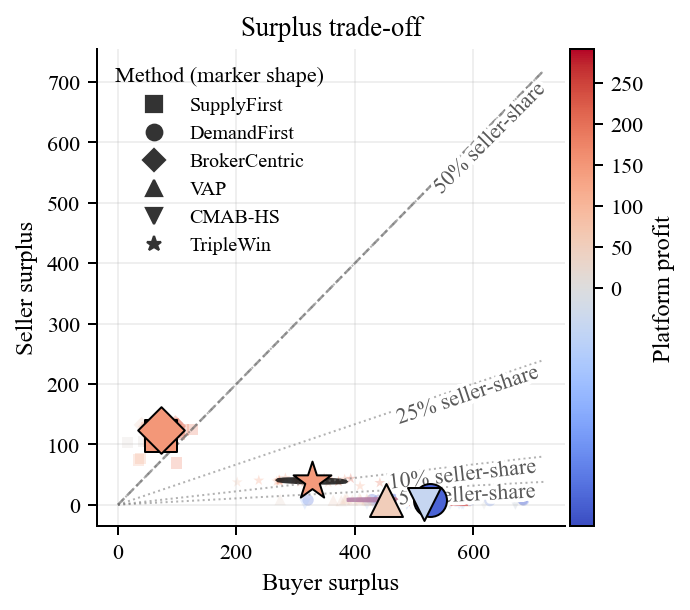

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Output directory (safe default)
OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(4.2, 3.7), constrained_layout=True)

# Color encodes platform profit (diverging around 0)
pp = df["platform_profit"].to_numpy(dtype=float)
norm = TwoSlopeNorm(vmin=np.nanmin(pp), vcenter=0.0, vmax=np.nanmax(pp))
cmap = plt.get_cmap("coolwarm")

# Plot per-trial clouds (shape=method, color=platform profit)
for method in METHOD_ORDER:
    g = df[df["method"] == method]

    ax.scatter(
        g["buyer_surplus"], g["seller_surplus"],
        c=g["platform_profit"], cmap=cmap, norm=norm,
        marker=MARKERS[method],
        s=26, alpha=0.28, linewidths=0.0,
        rasterized=True
    )

# Overlay mean points + 1σ ellipse + labels
label_offsets = {
    "SupplyFirst": (8, 8),
    "BrokerCentric": (8, 10),
    "DemandFirst": (8, 8),
    "VAP": (8, 8),
    "CMAB-HS": (8, 8),
    "TripleWin": (8, 8),
}

for method in METHOD_ORDER:
    g = df[df["method"] == method]
    mx = float(np.nanmean(g["buyer_surplus"]))
    my = float(np.nanmean(g["seller_surplus"]))
    mpp = float(np.nanmean(g["platform_profit"]))

    # 1σ ellipse
    confidence_ellipse(
        g["buyer_surplus"], g["seller_surplus"],
        ax, n_std=1.0,
        facecolor="none", edgecolor=METHOD_COLORS[method],
        linewidth=1.6, alpha=0.85
    )

    # mean marker
    ax.scatter(
        [mx], [my],
        c=[mpp], cmap=cmap, norm=norm,
        marker=MARKERS[method],
        s=220 if method != "TripleWin" else 320,
        edgecolor="k", linewidths=0.9,
        zorder=10
    )

    # label
    dx, dy = label_offsets.get(method, (8, 8))
    # txt = ax.annotate(
    #     method, (mx, my),
    #     xytext=(dx, dy), textcoords="offset points",
    #     ha="left", va="bottom",
    #     fontsize=10, color="black", zorder=20
    # )
    # txt.set_path_effects(_text_stroke())

# Reference: equal buyer/seller surplus
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ref_max = max(xmax, ymax)
ax.plot([0, ref_max], [0, ref_max], ls="--", lw=1.1, color="0.35", alpha=0.6)

# Seller-share rays: y = (s/(1-s)) x
xmax_plot = max(df["buyer_surplus"].max(), 1.0) * 1.05
shares = [0.05, 0.10, 0.25, 0.50]
for s in shares:
    slope = s / (1 - s)
    xs = np.array([0, xmax_plot])
    ys = slope * xs
    ax.plot(xs, ys, ls=":", lw=0.9, color="0.45", alpha=0.55)
    # label near the end
    lx, ly = xs[-1], ys[-1]
    angle = np.degrees(np.arctan2(ys[-1] - ys[0], xs[-1] - xs[0]))
    lab = ax.text(
        lx * 0.98, ly * 0.98, f"{int(s*100)}% seller-share",
        fontsize=10, color="0.35",
        ha="right", va="top", rotation=angle,
        rotation_mode="anchor"
    )
    lab.set_path_effects(_text_stroke())

ax.grid(True)
ax.set_xlabel("Buyer surplus", fontsize=11)
ax.set_ylabel("Seller surplus", fontsize=11)
ax.set_title("Surplus trade-off", fontsize=12)

# Colorbar
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.01)
cb.set_label("Platform profit")

# Optional: compact marker legend (shapes only)
handles = [
    Line2D([0], [0], marker=MARKERS[m], lw=0,
           markerfacecolor="0.2", markeredgecolor="0.2",
           label=m, markersize=7)
    for m in METHOD_ORDER
]
ax.legend(handles=handles, title="Method (marker shape)", loc="upper left", frameon=False)

# Save
# fig.savefig(OUT_DIR / "fig1_buyer_vs_seller_surplus.png", dpi=600, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig1_buyer_vs_seller_surplus.pdf", bbox_inches="tight")
plt.show()


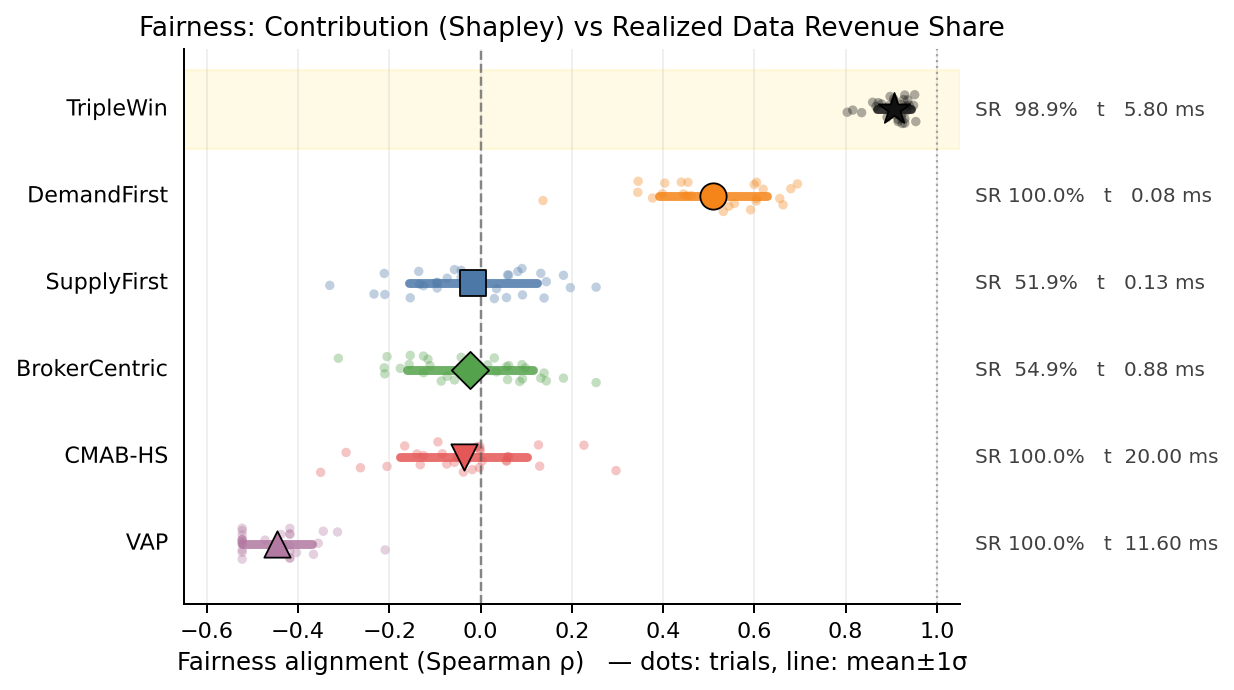

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.2, 3.7), constrained_layout=True)

# Order by mean fairness (so the story reads naturally), but keep TripleWin visible
means = df.groupby("method")["fairness"].mean().reindex(METHOD_ORDER)
methods_sorted = list(means.sort_values(ascending=True).index)

# y positions
ypos = np.arange(len(methods_sorted))

# background highlight for TripleWin row
tw_i = methods_sorted.index("TripleWin")
ax.axhspan(tw_i - 0.45, tw_i + 0.45, color="#FFD700", alpha=0.10, zorder=0)

rng = np.random.default_rng(7)
xaxis_ydata = blended_transform_factory(ax.transAxes, ax.transData)

for i, method in enumerate(methods_sorted):
    g = df[df["method"] == method]
    vals = g["fairness"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        continue

    # jittered points (trial-level)
    jitter = rng.uniform(-0.18, 0.18, size=vals.size)
    ax.scatter(
        vals, i + jitter,
        s=18, alpha=0.35,
        color=METHOD_COLORS[method],
        edgecolor="none",
        rasterized=True
    )

    mu = float(np.mean(vals))
    sd = float(np.std(vals))

    # mean ± 1σ
    ax.plot([mu - sd, mu + sd], [i, i],
            lw=4.0, color=METHOD_COLORS[method], alpha=0.85, solid_capstyle="round")

    # mean marker
    ax.scatter(
        [mu], [i],
        s=140 if method != "TripleWin" else 220,
        marker=MARKERS[method],
        color=METHOD_COLORS[method],
        edgecolor="k", linewidth=0.8, zorder=5
    )

    # left method label (cleaner than ytick text if you want)
    ax.text(-0.02, i, method, transform=xaxis_ydata, ha="right", va="center",
            fontsize=10, color="black", clip_on=False).set_path_effects(_text_stroke())

    # right-side compact annotations: success rate + runtime
    sr = float(g["trans_rate"].mean()) * 100.0
    rt = float(g["runtime_s"].mean()) * 1000.0  # ms
    ax.text(1.02, i, f"SR {sr:5.1f}%   t {rt:6.2f} ms",
            transform=xaxis_ydata, ha="left", va="center",
            fontsize=9, color="0.25", clip_on=False)

# Reference lines
ax.axvline(0.0, ls="--", lw=1.1, color="0.35", alpha=0.7)
ax.axvline(1.0, ls=":", lw=1.0, color="0.35", alpha=0.5)
ax.axvline(-1.0, ls=":", lw=1.0, color="0.35", alpha=0.5)

ax.set_yticks([])  # we print method names manually
ax.set_ylim(-0.7, len(methods_sorted) - 0.3)
ax.set_xlim(-0.65, 1.05)

ax.grid(True, axis="x")
ax.set_xlabel("Fairness alignment (Spearman ρ)", fontsize=11) #   — dots: trials, line: mean±1σ
# ax.set_ylabel(fontsize=11)
ax.set_title("Fairness", fontsize=12)

# Save
fig.savefig(OUT_DIR / "fig2_fairness_rho.png", dpi=600, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig2_fairness_rho.pdf", bbox_inches="tight")
plt.show()


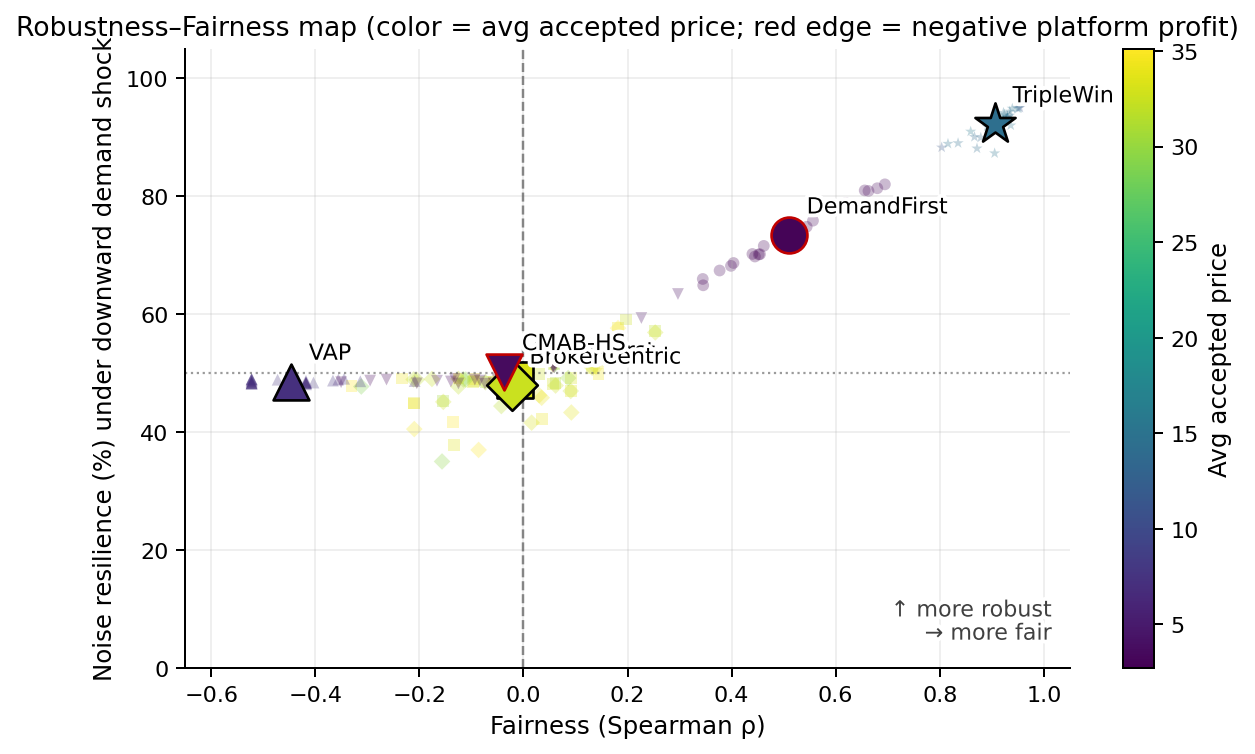

In [23]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)

# x: fairness, y: noise resilience (%)
x = df["fairness"].to_numpy(dtype=float)
y = (df["noise_resil"].to_numpy(dtype=float) * 100.0)
price = df["avg_price"].to_numpy(dtype=float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(price)
x, y, price = x[mask], y[mask], price[mask]
dfp = df.loc[mask].copy()

# Color encodes Avg Price (gives a 3rd dimension; visually clean)
norm = Normalize(vmin=np.nanpercentile(price, 2), vmax=np.nanpercentile(price, 98))
cmap = plt.get_cmap("viridis")

# Per-trial clouds
for method in METHOD_ORDER:
    g = dfp[dfp["method"] == method]
    ax.scatter(
        g["fairness"], g["noise_resil"] * 100.0,
        c=g["avg_price"], cmap=cmap, norm=norm,
        marker=MARKERS[method],
        s=28, alpha=0.28, linewidths=0.0,
        rasterized=True
    )

# Mean markers + labels (edge color shows platform profit sign)
for method in METHOD_ORDER:
    g = dfp[dfp["method"] == method]
    mx = float(np.nanmean(g["fairness"]))
    my = float(np.nanmean(g["noise_resil"] * 100.0))
    mp = float(np.nanmean(g["avg_price"]))
    mpp = float(np.nanmean(g["platform_profit"]))

    edge = "#C00000" if mpp < 0 else "k"  # red edge if platform profit is negative

    ax.scatter(
        [mx], [my],
        c=[mp], cmap=cmap, norm=norm,
        marker=MARKERS[method],
        s=260 if method != "TripleWin" else 360,
        edgecolor=edge, linewidths=1.2, zorder=10
    )

    txt = ax.annotate(
        method, (mx, my),
        xytext=(8, 8), textcoords="offset points",
        ha="left", va="bottom", fontsize=10, color="black", zorder=20
    )
    txt.set_path_effects(_text_stroke())

# Quadrant-ish references
ax.axvline(0.0, ls="--", lw=1.1, color="0.35", alpha=0.7)
ax.axhline(50.0, ls=":", lw=1.0, color="0.35", alpha=0.6)
ax.text(0.98, 0.04, "↑ more robust\n→ more fair",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=10, color="0.25").set_path_effects(_text_stroke())

ax.grid(True)
ax.set_xlim(-0.65, 1.05)
ax.set_ylim(0, 105)

ax.set_xlabel("Fairness (Spearman ρ)")
ax.set_ylabel("Noise resilience (%) under downward demand shock")
ax.set_title("Robustness–Fairness map (color = avg accepted price; red edge = negative platform profit)")

cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.01)
cb.set_label("Avg accepted price")

# Save
fig.savefig(OUT_DIR / "fig3_noise_resilience.png", dpi=600, bbox_inches="tight")
fig.savefig(OUT_DIR / "fig3_noise_resilience.pdf", bbox_inches="tight")
plt.show()
